# 状态--核心原语
可以理解为智能体的“短期记忆”，它可以存储智能体的当前状态、环境信息、历史交互记录等

## 使用 TypedDictState 和 PydanticState 定义状态

In [6]:
# TypedDictState
from typing_extensions import TypedDict

class TypedDictState(TypedDict):
    user_input: str
    agent_response: str
    tool_output: str


# PydanticState
from pydantic import BaseModel, field_validator

class PydanticState(BaseModel):
    user_input: str
    agent_response: str
    tool_output: str
    mood: str = 'happy'     # 默认情绪状态为happy

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        if value not in ['happy', 'sad', 'angry']:
            raise ValueError('mood must be happy, sad, or angry')
        return value

## 状态归约器

In [12]:
from typing_extensions import TypedDict, Annotated

from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

class ChatState(TypedDict):
    user_input: str
    # 消息历史 指定add_messages归约器，当多个节点同时更新message_history时，会将消息追加而不是覆盖
    message_history: Annotated[list[BaseMessage], add_messages]
    tool_output: str

print("演示 add_messages Reducer：")

# 初始状态
initial_state = {
    "message_history": [HumanMessage(content="Hello")],
    "user_intent": "greeting",
    "tool_output": ""
}
print("初始状态:")
for msg in initial_state["message_history"]:
    print(f"  {type(msg).__name__}: {msg.content}")

# 新的消息更新
new_messages = [AIMessage(content="Hi there! How can I help you?")]
print("\n添加新消息:")
for msg in new_messages:
    print(f"  {type(msg).__name__}: {msg.content}")

# add_messages Reducer 会自动合并消息
updated_messages = add_messages(initial_state["message_history"], new_messages)

print("\n合并后的消息历史:（可以看到消息历史被合并了，而不是被覆盖）")
for msg in updated_messages:
    print(f"  {type(msg).__name__}: {msg.content}")

演示 add_messages Reducer：
初始状态:
  HumanMessage: Hello

添加新消息:
  AIMessage: Hi there! How can I help you?

合并后的消息历史:（可以看到消息历史被合并了，而不是被覆盖）
  HumanMessage: Hello
  AIMessage: Hi there! How can I help you?


## 自定义状态归约器

In [13]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import BaseMessage

# 定义状态归约器-功能：将新列表加入到已有列表末尾并去重
def reducer_extend_unique(left: list | None, right: list | None) -> list:
    existing_items = left if left else []
    new_items = right if right else []

    combined_items = existing_items + new_items
    return list(set(combined_items))

class ChatState(TypedDict):
    message_history: Annotated[list[BaseMessage], reducer_extend_unique]
    user_input: str
    tool_output: str
    item_list: Annotated[list[str], reducer_extend_unique]

# 测试自定义 Reducer
print("测试自定义 Reducer：")
print("="*50)

existing_list = ["apple", "banana", "orange"]
new_list = ["banana", "grape", "apple", "mango"]

print(f"已有列表: {existing_list}")
print(f"新增列表: {new_list}")

result = reducer_extend_unique(existing_list, new_list)
print(f"合并去重结果: {result}")

测试自定义 Reducer：
已有列表: ['apple', 'banana', 'orange']
新增列表: ['banana', 'grape', 'apple', 'mango']
合并去重结果: ['banana', 'orange', 'mango', 'grape', 'apple']


## 使用 MessageState
> MessageState的核心特性是开箱即用、高度优化、可扩展； 默认 add_messages Reducer：自动处理消息追加、更新和去重；消息序列化与反序列化：支持 JSON 兼容的字典格式传递消息数据

In [14]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage

class MyChatState(MessagesState):
    """
    自定义的 ChatState, 继承自 MessagesState, 
    自动包含 messages 状态键和 add_messages Reducer
    """
    user_intent: str
    tool_output: str
    # ... 可以添加其他自定义的状态键 ...

print("演示不同类型的消息：")

human_msg = HumanMessage(content="你好，我想查询今天的天气")
system_msg = SystemMessage(content="你是一个专业的天气助手，请友好地回复用户")
ai_msg = AIMessage(content="好的，我来帮你查询天气信息")
tool_msg = ToolMessage(content="北京今天晴转多云，温度 20-28°C", tool_call_id="weather_001")

messages = [system_msg, human_msg, ai_msg, tool_msg]

for i, msg in enumerate(messages, 1):
    print(f"{i}. {type(msg).__name__}: {msg.content}")


# 演示 MessagesState 的使用
print("\n演示 MessagesState 的状态管理：")
chat_state = {
    "messages": messages,
    "user_intent": "weather_query",
    "tool_output": "weather_data_retrieved"
}

print(f"对话轮次: {len(chat_state['messages'])}")
print(f"用户意图: {chat_state['user_intent']}")
print(f"工具输出: {chat_state['tool_output']}")


演示不同类型的消息：
1. SystemMessage: 你是一个专业的天气助手，请友好地回复用户
2. HumanMessage: 你好，我想查询今天的天气
3. AIMessage: 好的，我来帮你查询天气信息
4. ToolMessage: 北京今天晴转多云，温度 20-28°C

演示 MessagesState 的状态管理：
对话轮次: 4
用户意图: weather_query
工具输出: weather_data_retrieved


## trim_messages 和 RemoveMessage
* trim_messages 用于修剪消息历史，保留最近的消息
* RemoveMessage 用于从消息历史中删除指定消息

In [17]:

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, trim_messages, RemoveMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import count_tokens_approximately
import os
from dotenv import load_dotenv

load_dotenv()
print(f"测试环境变量: {os.getenv('OPENAI_API_KEY')}")

llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
)
# 使用 trim_messages 的节点
def llm_node_with_trim(state: MessagesState):
    print("🤖 LLM节点 (使用 trim_messages)")
    message_history = state['messages']
    print(f"📥 接收到 {len(message_history)} 条消息")

    # 显示原始消息
    for i, msg in enumerate(message_history):
        content_preview = msg.content[:50] + "..." if len(msg.content) > 50 else msg.content
        print(f"  {i+1}. [{msg.__class__.__name__}] {content_preview}")

    # 使用 trim_messages 修剪消息历史
    trimmed_messages = trim_messages(
        message_history,
        max_tokens=200,  # 降低限制以便看到修剪效果
        strategy="last",
        token_counter=count_tokens_approximately,
        allow_partial=False
    )

    print(f"✂️ 修剪后保留 {len(trimmed_messages)} 条消息 (token限制: 200)")

    # 生成回复
    llm_response = llm.invoke(trimmed_messages)
    print(f"💭 生成回复: {llm_response.content}")

    return {"messages": [llm_response]}

# 使用 filter_messages 的节点 (基于 RemoveMessage)
def filter_node(state: MessagesState):
    print("\n🔧 过滤节点 (使用 RemoveMessage)")
    message_history = state['messages']
    print(f"📥 接收到 {len(message_history)} 条消息")

    remove_messages = []

    # 过滤策略：移除包含"你好"或"再见"的寒暄消息
    for msg in message_history:
        if any(greeting in msg.content.lower() for greeting in ["你好", "再见", "hello", "bye"]):
            print(f"🗑️ 标记移除寒暄消息: {msg.content[:30]}...")
            # 不是直接把消息从 message_history 列表里 pop 或 del 掉。
            # 而是创建一条特殊的“指令消息” (RemoveMessage)，告诉 LangGraph 的 MessagesState： “请删除一条 id = msg.id 的消息”。
            remove_messages.append(RemoveMessage(id=msg.id))
        # 移除过长的消息
        elif len(msg.content) > 100:
            print(f"🗑️ 标记移除过长消息: {msg.content[:30]}...")
            remove_messages.append(RemoveMessage(id=msg.id))

    if remove_messages:
        print(f"📊 将移除 {len(remove_messages)} 条消息")
        return {"messages": remove_messages}
    else:
        print("✅ 没有需要移除的消息")
        return {}
    
# 添加用户消息的节点
def add_user_message(state: MessagesState):
    print("\n👤 添加用户消息节点")
    new_message = HumanMessage(content="我想了解人工智能的最新发展，特别是在自然语言处理方面的突破。")
    print(f"➕ 添加消息: {new_message.content}")
    return {"messages": [new_message]}

# 创建图
print("🏗️ 构建消息管理示例图...")
builder = StateGraph(MessagesState)

# 添加节点
builder.add_node("add_message", add_user_message)
builder.add_node("filter", filter_node)
builder.add_node("llm_trim", llm_node_with_trim)

# 定义边
builder.add_edge(START, "add_message")
builder.add_edge("add_message", "filter")
builder.add_edge("filter", "llm_trim")
builder.add_edge("llm_trim", END)

# 编译图
graph = builder.compile()
print("✅ 图构建完成！")

# 准备初始消息历史
print("\n=== 🚀 消息状态管理示例 ===")

initial_messages = [
    SystemMessage(content="你是一个专业的AI助手，擅长回答各种问题。"),
    HumanMessage(content="你好！很高兴见到你。"),
    AIMessage(content="你好！我也很高兴为您服务。有什么可以帮助您的吗？"),
    HumanMessage(content="这是一条很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长的测试消息，用来测试过滤功能。"),
    AIMessage(content="我明白了您的测试消息。"),
    HumanMessage(content="再见！"),
]

print("📋 初始消息历史:")
for i, msg in enumerate(initial_messages):
    content_preview = msg.content[:40] + "..." if len(msg.content) > 40 else msg.content
    print(f"  {i+1}. [{msg.__class__.__name__}] {content_preview}")

# 运行图
result = graph.invoke({"messages": initial_messages})

print(f"\n=== ✨ 最终结果 ===")
print(f"📊 最终消息历史包含 {len(result['messages'])} 条消息:")
for i, msg in enumerate(result['messages']):
    content_preview = msg.content[:50] + "..." if len(msg.content) > 50 else msg.content
    print(f"  {i+1}. [{msg.__class__.__name__}] {content_preview}")

测试环境变量: sk-52338e5bc4704f45b2dbadc410b0daf8
🏗️ 构建消息管理示例图...
✅ 图构建完成！

=== 🚀 消息状态管理示例 ===
📋 初始消息历史:
  1. [SystemMessage] 你是一个专业的AI助手，擅长回答各种问题。
  2. [HumanMessage] 你好！很高兴见到你。
  3. [AIMessage] 你好！我也很高兴为您服务。有什么可以帮助您的吗？
  4. [HumanMessage] 这是一条很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长...
  5. [AIMessage] 我明白了您的测试消息。
  6. [HumanMessage] 再见！

👤 添加用户消息节点
➕ 添加消息: 我想了解人工智能的最新发展，特别是在自然语言处理方面的突破。

🔧 过滤节点 (使用 RemoveMessage)
📥 接收到 7 条消息
🗑️ 标记移除寒暄消息: 你好！很高兴见到你。...
🗑️ 标记移除寒暄消息: 你好！我也很高兴为您服务。有什么可以帮助您的吗？...
🗑️ 标记移除寒暄消息: 再见！...
📊 将移除 3 条消息
🤖 LLM节点 (使用 trim_messages)
📥 接收到 4 条消息
  1. [SystemMessage] 你是一个专业的AI助手，擅长回答各种问题。
  2. [HumanMessage] 这是一条很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长很长的测试消息，用来测试...
  3. [AIMessage] 我明白了您的测试消息。
  4. [HumanMessage] 我想了解人工智能的最新发展，特别是在自然语言处理方面的突破。
✂️ 修剪后保留 4 条消息 (token限制: 200)
💭 生成回复: 自然语言处理（NLP）是人工智能领域近年来发展最快的分支之一，尤其在深度学习、预训练语言模型和多模态技术的推动下，取得了许多令人瞩目的突破。以下是一些2023-2024年期间在NLP领域的重要进展和趋势：

---

### 1. **大语言模型（LLM）持续进化**
大语言模型已经成为NLP的核心技术之一，代表模型包括：

- **GPT-4**（OpenAI）：虽然尚未正式发布所有细节，但GPT-4在

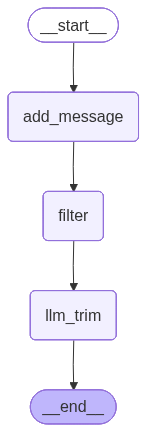

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass